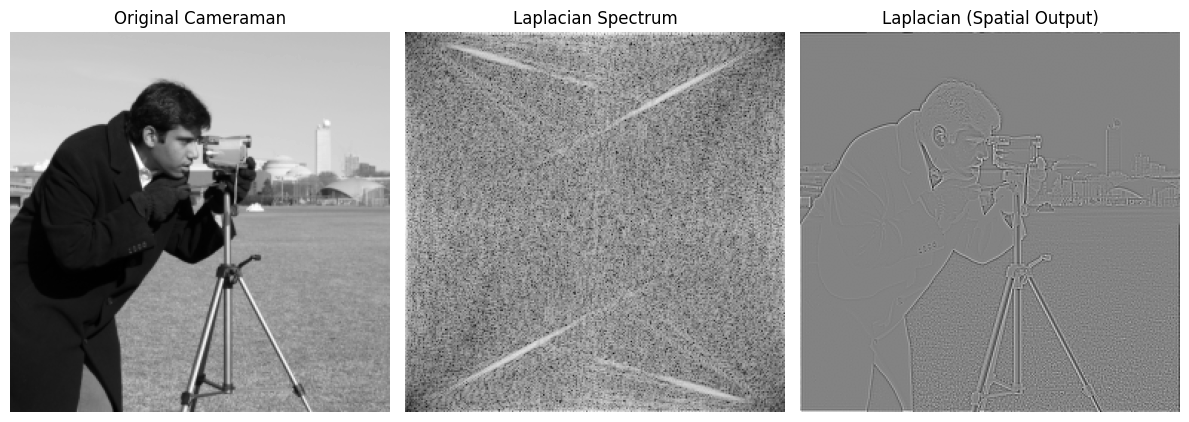

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()


## Task 1:

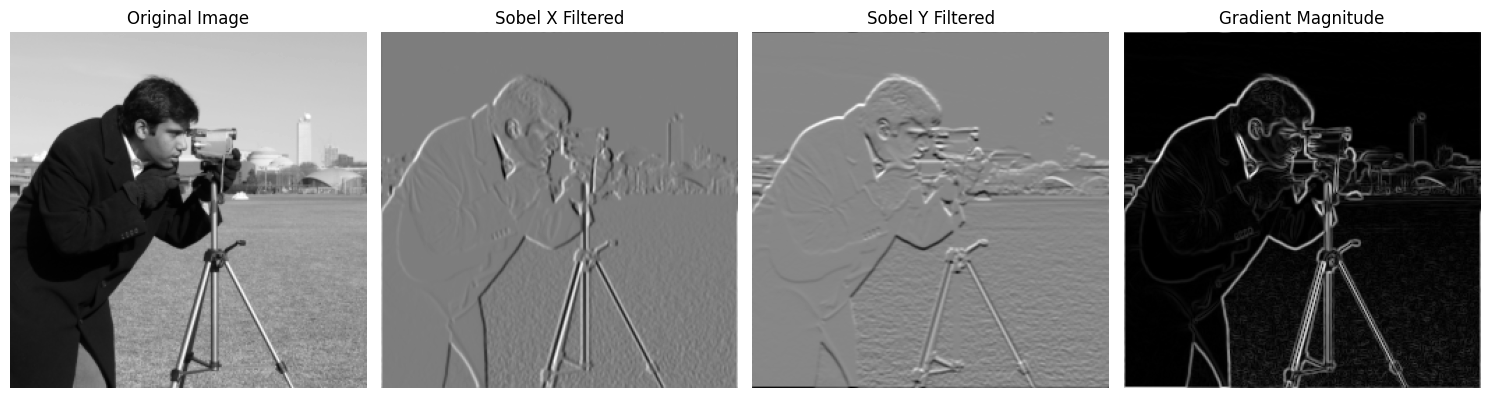

In [2]:

from numpy.fft import fft2, ifft2, ifftshift

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))  # Shift before FFT to place (0,0) at top-left

# Compute FFT of image
F_image = fft2(image)

# FFT of centered Sobel filters (use the provided function)
H_sobel_x = center_embed_kernel(sobel_x, image.shape)
H_sobel_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_out_x = F_image * H_sobel_x
F_out_y = F_image * H_sobel_y

# Inverse FFT to get spatial results (take real part to handle numerical artifacts)
out_x = ifft2(F_out_x).real
out_y = ifft2(F_out_y).real

# Compute gradient magnitude
magnitude = np.sqrt(out_x**2 + out_y**2)

# Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(out_x, cmap='gray')
plt.title('Sobel X Filtered')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(out_y, cmap='gray')
plt.title('Sobel Y Filtered')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()